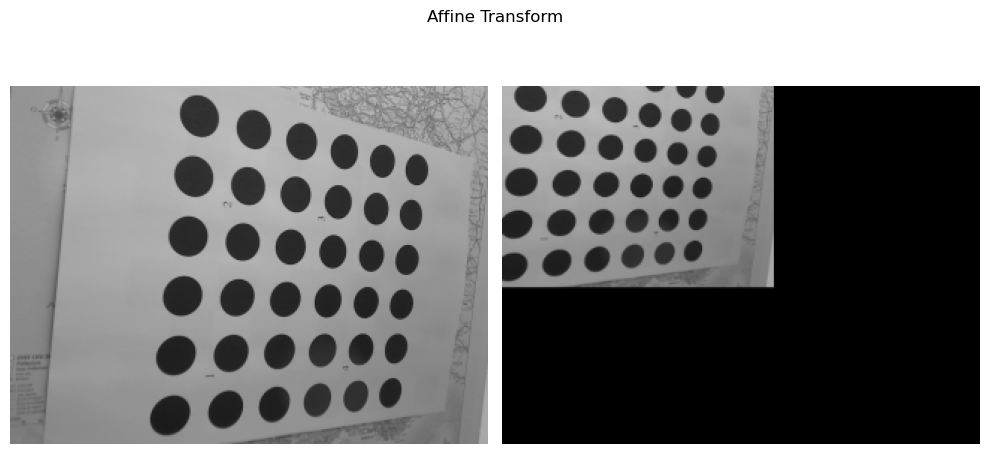

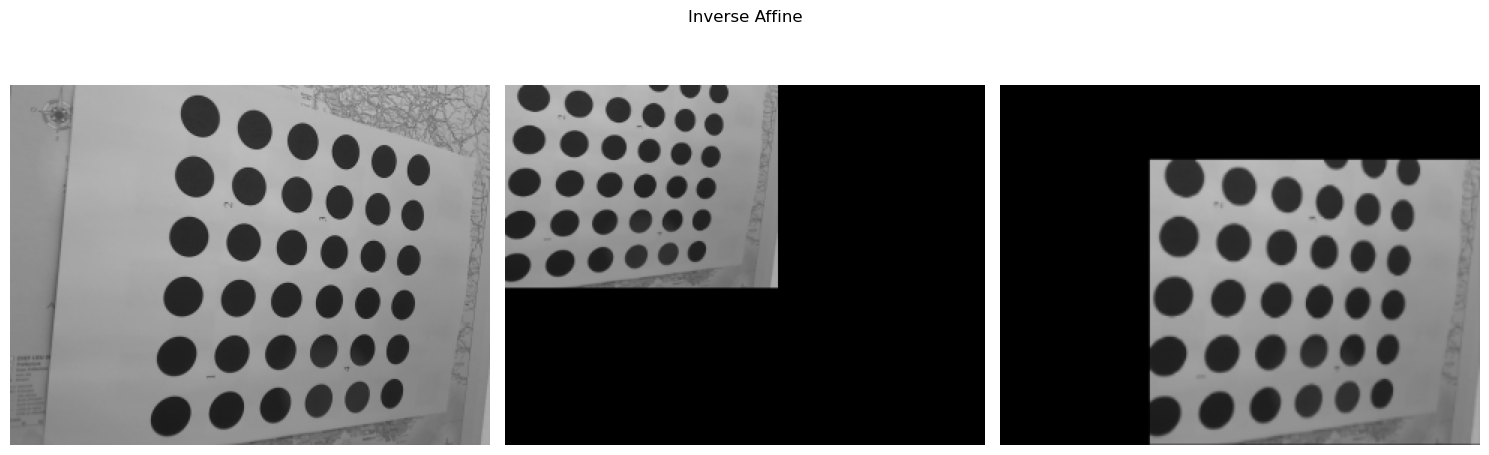

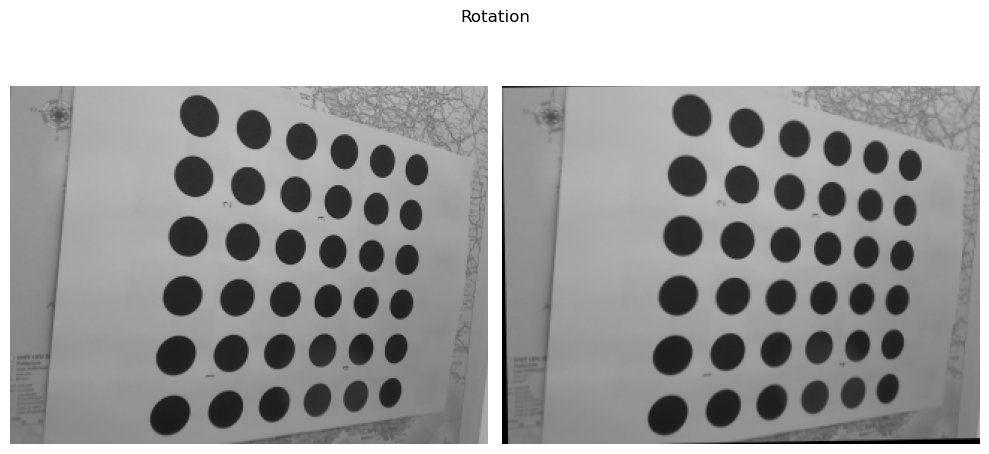

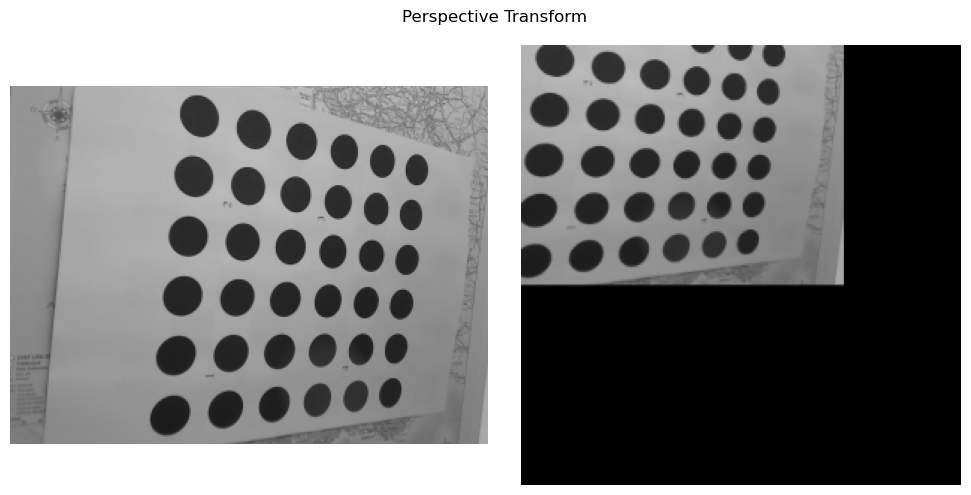

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('./circlesgrid.png', cv2.IMREAD_COLOR)
show_img = np.copy(img)

def imshow(title, *images):
    n = len(images)
    plt.figure(figsize=(5 * n, 5))
    plt.suptitle(title)
    for i, im in enumerate(images):
        plt.subplot(1, n, i + 1)
        plt.axis('off')
        plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    plt.tight_layout()
    plt.show()

# 어파인 변환 (점 3개 직접 지정)
src_pts = np.array([[100, 400], [100, 50], [400, 50]], dtype=np.float32)
dst_pts = np.array([[0, 249], [0, 0], [248, 0]], dtype=np.float32)

affine_m = cv2.getAffineTransform(src_pts, dst_pts)
unwarped_img = cv2.warpAffine(img, affine_m, (320, 240))
imshow('Affine Transform', show_img, unwarped_img)

inv_affine = cv2.invertAffineTransform(affine_m)
warped_img = cv2.warpAffine(unwarped_img, inv_affine, (320, 240))
imshow('Inverse Affine', show_img, unwarped_img, warped_img)

rotation_mat = cv2.getRotationMatrix2D((src_pts[0][0], 0), 1, 1.0)
rotated_img = cv2.warpAffine(img, rotation_mat, (320, 240))
imshow('Rotation', show_img, rotated_img)

# 원근 변환 (점 4개 직접 지정)
src_pts4 = np.array([[100, 400], [100, 50], [400, 50], [400, 400]], dtype=np.float32)
dst_pts4 = np.array([[0, 249], [0, 0], [248, 0], [248, 249]], dtype=np.float32)

perspective_m = cv2.getPerspectiveTransform(src_pts4, dst_pts4)
unwarped_img2 = cv2.warpPerspective(img, perspective_m, (248, 248))
imshow('Perspective Transform', show_img, unwarped_img2)


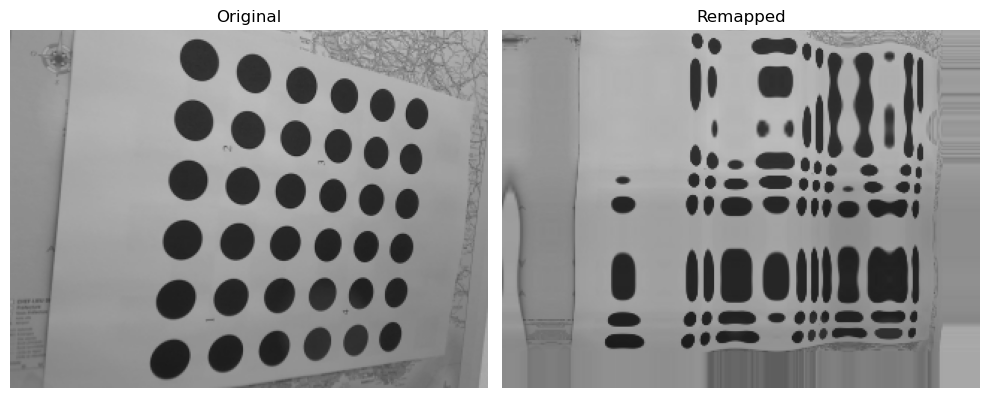

In [6]:
import math
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('./circlesgrid.png')

xmap = np.zeros((img.shape[0], img.shape[1]), np.float32)
ymap = np.zeros((img.shape[0], img.shape[1]), np.float32)
for y in range(img.shape[0]):
    for x in range(img.shape[1]):
        xmap[y, x] = x + 30 * math.cos(20 * x / img.shape[0])
        ymap[y, x] = y + 30 * math.sin(20 * y / img.shape[1])

remapped_img = cv2.remap(img, xmap, ymap, cv2.INTER_LINEAR, None, cv2.BORDER_REPLICATE)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original')
plt.axis('off')
plt.imshow(img[:, :, [2, 1, 0]])
plt.subplot(1, 2, 2)
plt.title('Remapped')
plt.axis('off')
plt.imshow(remapped_img[:, :, [2, 1, 0]])
plt.tight_layout()
plt.show()

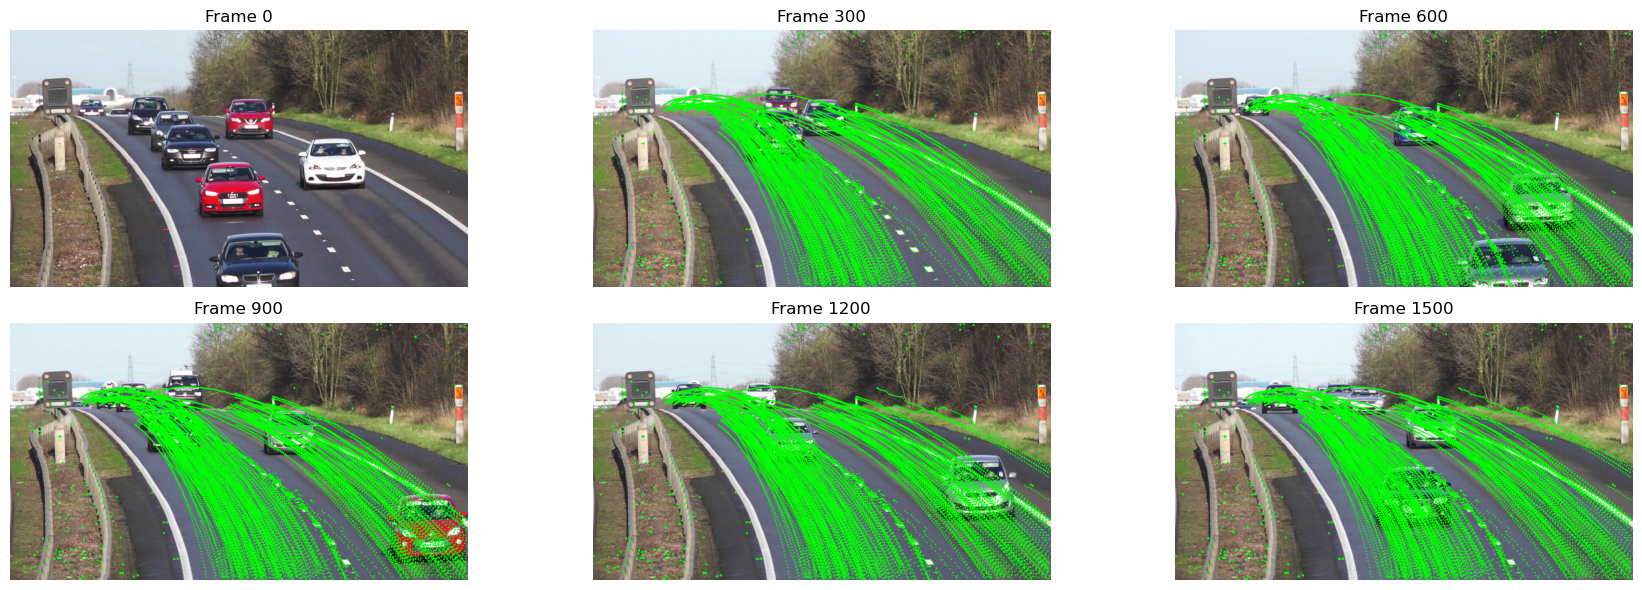

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

video = cv2.VideoCapture('./traffic.mp4')
prev_pts = None
prev_gray_frame = None
tracks = None

display_frames = []

while True:
    retval, frame = video.read()
    if not retval: break
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if prev_pts is not None:
        pts, status, errors = cv2.calcOpticalFlowPyrLK(
            prev_gray_frame, gray_frame, prev_pts, None,
            winSize=(15, 15), maxLevel=5,
            criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))
        good_pts = pts[status == 1]
        if tracks is None: tracks = good_pts
        else: tracks = np.vstack((tracks, good_pts))
        for p in tracks:
            cv2.circle(frame, (int(p[0]), int(p[1])), 3, (0, 255, 0), -1)
    else:
        pts = cv2.goodFeaturesToTrack(gray_frame, 500, 0.05, 10)
        pts = pts.reshape(-1, 1, 2)

    prev_pts = pts
    prev_gray_frame = gray_frame
    display_frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

video.release()

# 균등 간격으로 6프레임 출력
indices = np.linspace(0, len(display_frames) - 1, 6, dtype=int)
plt.figure(figsize=(18, 6))
for i, idx in enumerate(indices):
    plt.subplot(2, 3, i + 1)
    plt.title(f'Frame {idx}')
    plt.axis('off')
    plt.imshow(display_frames[idx])
plt.tight_layout()
plt.show()